In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow Version:", tf.__version__)
# Memastikan GPU kamu aktif
print("GPU Tersedia:" if tf.config.list_physical_devices('GPU') else "GPU TIDAK Tersedia, cek langkah 1 lagi!")

TensorFlow Version: 2.20.0
GPU Tersedia:


In [3]:
# 1. Download dataset bawaan CIFAR-10
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# Di CIFAR-10, indeks 3 adalah Kucing (Cat) dan indeks 5 adalah Anjing (Dog)
# Kita filter datanya biar cuma dapet dua kelas ini
def filter_dua_kelas(x, y):
    mask = (y == 3) | (y == 5)
    x_filtered = x[mask.squeeze()]
    y_filtered = y[mask.squeeze()]
    # Ubah label: 3 (Cat) jadi 0, 5 (Dog) jadi 1
    y_filtered = np.where(y_filtered == 3, 0, 1)
    return x_filtered, y_filtered

x_cifar, y_cifar = filter_dua_kelas(x_train_full, y_train_full)

# 2. Batasi jumlahnya sesuai ketentuan tugas (Minimal 100 per kelas untuk training)
# Kita ambil total 300 data biar pembagian 70:15:15 nya pas dan bulat
# 150 gambar Kucing, 150 gambar Anjing
cat_indices = np.where(y_cifar == 0)[0][:150]
dog_indices = np.where(y_cifar == 1)[0][:150]

all_indices = np.concatenate([cat_indices, dog_indices])
np.random.shuffle(all_indices) # Diacak biar adil

x_final = x_cifar[all_indices]
y_final = y_cifar[all_indices]

# 3. Split Data menjadi 70% Training, 15% Validation, 15% Testing
total_data = len(x_final)
tr_end = int(total_data * 0.70)
val_end = tr_end + int(total_data * 0.15)

x_train, y_train = x_final[:tr_end], y_final[:tr_end]
x_val, y_val = x_final[tr_end:val_end], y_final[tr_end:val_end]
x_test, y_test = x_final[val_end:], y_final[val_end:]

# Normalisasi pixel gambar dari 0-255 menjadi 0-1
x_train, x_val, x_test = x_train / 255.0, x_val / 255.0, x_test / 255.0

print(f"Data Training: {x_train.shape[0]} gambar")
print(f"Data Validation: {x_val.shape[0]} gambar")
print(f"Data Testing: {x_test.shape[0]} gambar")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7938s 47us/step
Data Training: 210 gambar
Data Validation: 45 gambar
Data Testing: 45 gambar


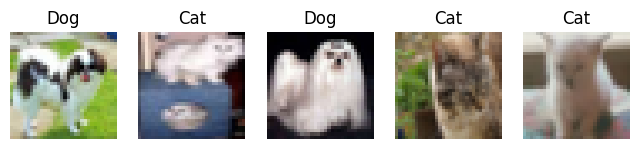

In [4]:
plt.figure(figsize=(8,3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i])
    plt.title("Cat" if y_train[i] == 0 else "Dog")
    plt.axis('off')
plt.show()

In [5]:
# Membuat model squential (berurutan dari input sampai output)
model_scratch = models.Sequential([
    # 1. Convolutional Layer + Activation ReLU
    # Menggunakan 32 filter berukuran 3x3 untuk mencari pola dasar (garis, sudut)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),

    # 2. Max Pooling Layer
    # Memperkecil ukuran gambar menjadi setengahnya agar komputasi lebih ringan
    layers.MaxPooling2D((2, 2)),

    # 3. Convolutional Layer ke-2 + Activation ReLU
    # Menggunakan 64 filter untuk menangkap pola yang lebih kompleks
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4. Flatten Layer
    # Mengubah matriks gambar 2D menjadi satu baris vektor 1D sebelum masuk ke klasifikasi
    layers.Flatten(),

    # 5. Dense Layer (Hidden Layer)
    # Memiliki 64 neuron untuk mempelajari kombinasi fitur yang sudah diekstrak
    layers.Dense(64, activation='relu'),

    # Tambahan Teknik Regularisasi: Dropout
    # Mematikan 50% neuron secara acak saat training agar model tidak malas/overfitting
    layers.Dropout(0.5),

    # 6. Output Layer (Sigmoid)
    # Menggunakan 1 neuron dengan fungsi aktivasi Sigmoid karena klasifikasi 2 kelas (Biner)
    # Output mendekati 0 = Kucing, mendekati 1 = Anjing
    layers.Dense(1, activation='sigmoid')
])

# Menampilkan ringkasan arsitektur model
model_scratch.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import time

# Menentukan taktik pembelajaran model
model_scratch.compile(
    optimizer='adam',                      # Optimizer populer yang stabil dan cepat
    loss='binary_crossentropy',            # Wajib untuk klasifikasi 2 kelas (biner)
    metrics=['accuracy']                   # Metrik yang dipantau adalah akurasi
)

# Menghitung waktu training dimulai
start_time = time.time()

# Proses Training!
print("Memulai Training CNN From Scratch...")
history_scratch = model_scratch.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,                         # Memproses data tiap 32 gambar
    validation_data=(x_val, y_val)
)

# Menghitung total waktu training
waktu_scratch = time.time() - start_time
print(f"\nTraining Selesai dalam: {waktu_scratch:.2f} detik!")

Memulai Training CNN From Scratch...
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 467ms/step - accuracy: 0.4810 - loss: 0.6978 - val_accuracy: 0.5778 - val_loss: 0.6857
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5571 - loss: 0.6887 - val_accuracy: 0.5556 - val_loss: 0.6856
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5095 - loss: 0.6957 - val_accuracy: 0.6000 - val_loss: 0.6697
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5952 - loss: 0.6769 - val_accuracy: 0.5556 - val_loss: 0.6900
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6381 - loss: 0.6585 - val_accuracy: 0.6444 - val_loss: 0.6576
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6571 - loss: 0.6414 - val_accuracy: 0.5778 - val_loss: 0.6631
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6143 - loss: 0.6272 - val_accuracy: 0.6222 - val_loss: 0.6773
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6714 - loss: 0.6372 - va

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models, layers

# 1. Mengambil 'otak' MobileNetV2 yang sudah pintar
# include_top=False artinya kita buang layer klasifikasi bawaannya karena kita mau pakai untuk 2 kelas saja
base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')

# 2. STRATEGI: Feature Extraction (Freeze Base Model)
# Kita kunci agar bobot asli MobileNetV2 tidak berubah/rusak selama training
base_model.trainable = False

# 3. Menyusun model baru dengan otak pretrained di dalamnya
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Mengubah matriks fitur menjadi vektor 1D
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),             # Regularisasi agar tidak overfitting
    layers.Dense(1, activation='sigmoid') # Output biner (0 atau 1)
])

# Tampilkan struktur modelnya
model_tl.summary()

/tmp/ipykernel_3347/2855890162.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
import time

# Taktik pembelajaran untuk Transfer Learning
model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Hitung waktu mulai
start_time_tl = time.time()

print("Memulai Training Model Transfer Learning...")
history_tl = model_tl.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_val, y_val)
)

# Hitung total waktu training
waktu_tl = time.time() - start_time_tl
print(f"\nTraining Transfer Learning Selesai dalam: {waktu_tl:.2f} detik!")

Memulai Training Model Transfer Learning...
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.4905 - loss: 0.6961 - val_accuracy: 0.5556 - val_loss: 0.7036
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5143 - loss: 0.6843 - val_accuracy: 0.4889 - val_loss: 0.7047
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5190 - loss: 0.6787 - val_accuracy: 0.4222 - val_loss: 0.7061
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5667 - loss: 0.6726 - val_accuracy: 0.4000 - val_loss: 0.7065
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5857 - loss: 0.6641 - val_accuracy: 0.4000 - val_loss: 0.7054
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6333 - loss: 0.6579 - val_accuracy: 0.4000 - val_loss: 0.7065
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5762 - loss: 0.6601 - val_accuracy: 0.4000 - val_loss: 0.7089
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6429 - loss: 0.6534

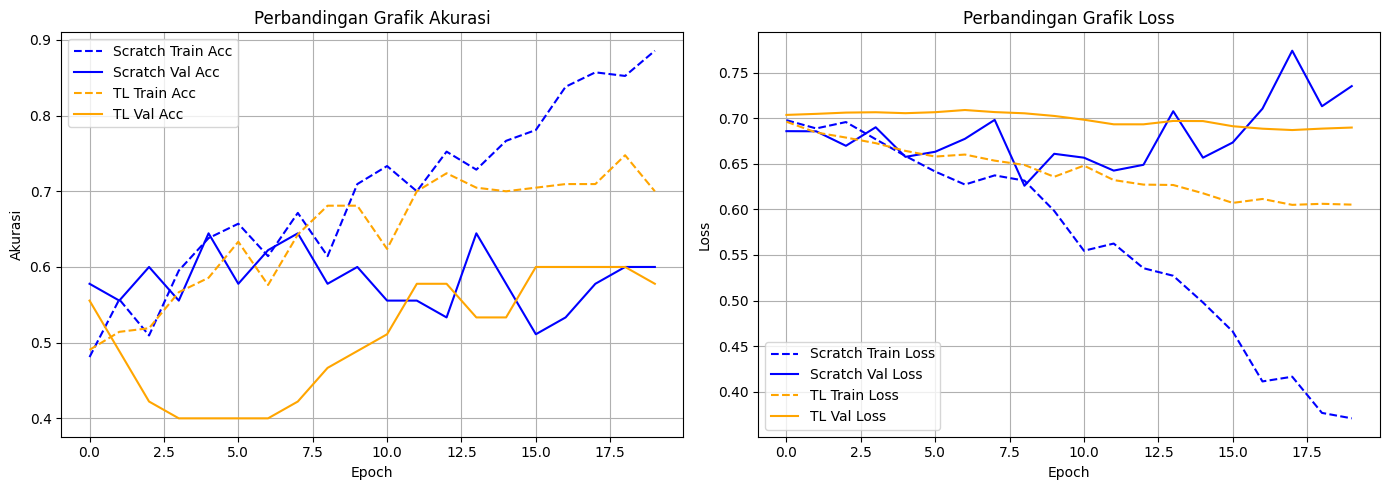

In [9]:
import matplotlib.pyplot as plt

# Membuat frame gambar
plt.figure(figsize=(14, 5))

# 1. Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['accuracy'], label='Scratch Train Acc', color='blue', linestyle='--')
plt.plot(history_scratch.history['val_accuracy'], label='Scratch Val Acc', color='blue')
plt.plot(history_tl.history['accuracy'], label='TL Train Acc', color='orange', linestyle='--')
plt.plot(history_tl.history['val_accuracy'], label='TL Val Acc', color='orange')
plt.title('Perbandingan Grafik Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# 2. Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['loss'], label='Scratch Train Loss', color='blue', linestyle='--')
plt.plot(history_scratch.history['val_loss'], label='Scratch Val Loss', color='blue')
plt.plot(history_tl.history['loss'], label='TL Train Loss', color='orange', linestyle='--')
plt.plot(history_tl.history['val_loss'], label='TL Val Loss', color='orange')
plt.title('Perbandingan Grafik Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

=== HASIL EVALUASI DATA TESTING ===
CNN From Scratch  -> Loss: 1.0713 | Akurasi: 48.89%
Transfer Learning -> Loss: 0.7693 | Akurasi: 42.22%



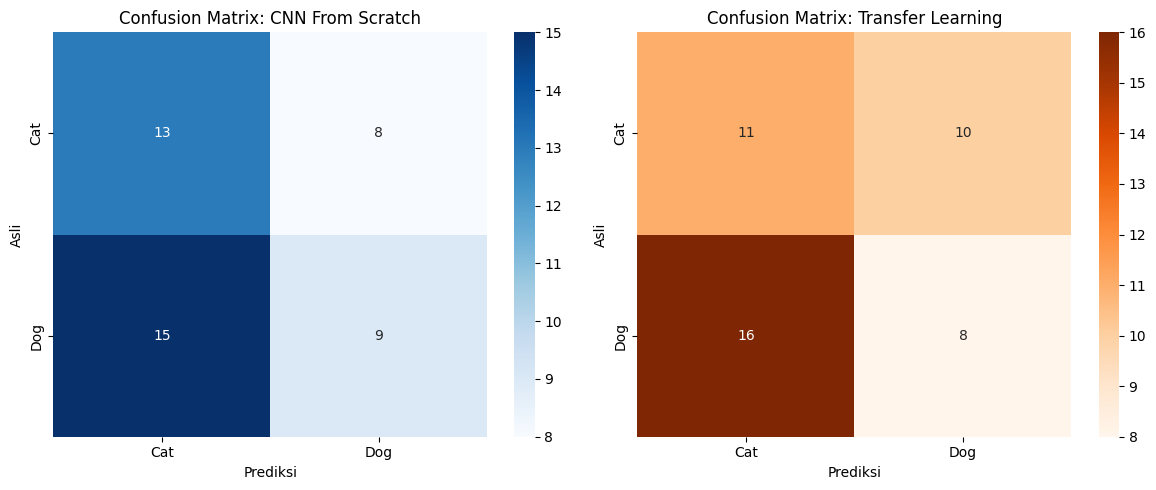

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Evaluasi ke Data Testing
loss_s, acc_s = model_scratch.evaluate(x_test, y_test, verbose=0)
loss_t, acc_t = model_tl.evaluate(x_test, y_test, verbose=0)

print(f"=== HASIL EVALUASI DATA TESTING ===")
print(f"CNN From Scratch  -> Loss: {loss_s:.4f} | Akurasi: {acc_s*100:.2f}%")
print(f"Transfer Learning -> Loss: {loss_t:.4f} | Akurasi: {acc_t*100:.2f}%\n")

# 2. Ambil Prediksi untuk Confusion Matrix
pred_scratch = (model_scratch.predict(x_test, verbose=0) > 0.5).astype(int)
pred_tl = (model_tl.predict(x_test, verbose=0) > 0.5).astype(int)

cm_scratch = confusion_matrix(y_test, pred_scratch)
cm_tl = confusion_matrix(y_test, pred_tl)

# 3. Plot Gambar Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
classes = ['Cat', 'Dog']

sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax[0])
ax[0].set_title('Confusion Matrix: CNN From Scratch')
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Asli')

sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax[1])
ax[1].set_title('Confusion Matrix: Transfer Learning')
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Asli')

plt.tight_layout()
plt.show()

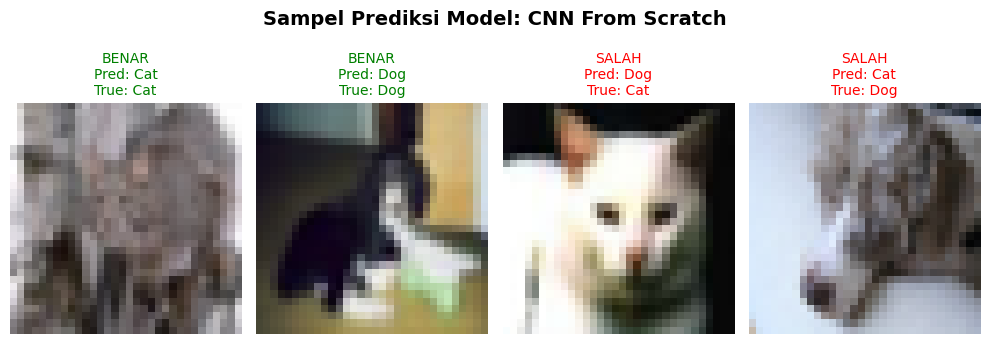

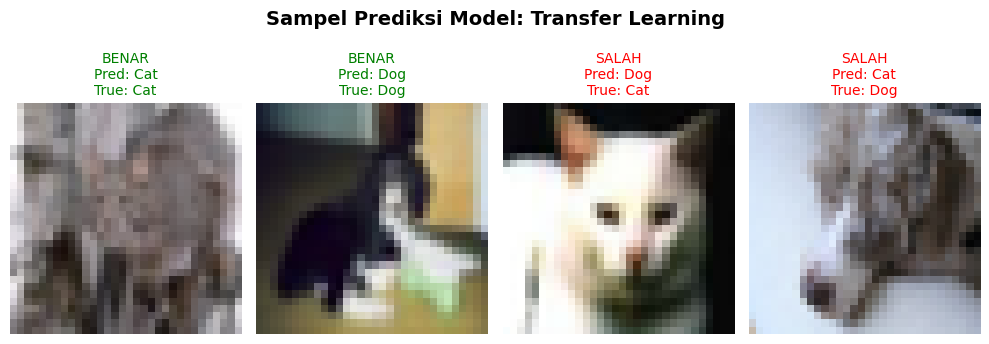

In [11]:
def plot_contoh_prediksi(model, title_name):
    preds = (model.predict(x_test, verbose=0) > 0.5).astype(int).squeeze()
    y_true = y_test.squeeze()

    # Cari indeks yang benar dan salah
    match_idx = np.where(preds == y_true)[0]
    miss_idx = np.where(preds != y_true)[0]

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"Sampel Prediksi Model: {title_name}", fontsize=14, weight='bold')

    # Tampilkan 2 yang Benar
    for i in range(2):
        idx = match_idx[i]
        plt.subplot(1, 4, i+1)
        plt.imshow(x_test[idx])
        plt.title(f"BENAR\nPred: {'Dog' if preds[idx]==1 else 'Cat'}\nTrue: {'Dog' if y_true[idx]==1 else 'Cat'}", color='green', fontsize=10)
        plt.axis('off')

    # Tampilkan 2 yang Salah (Jika ada)
    for i in range(2):
        if i < len(miss_idx):
            idx = miss_idx[i]
            plt.subplot(1, 4, i+3)
            plt.imshow(x_test[idx])
            plt.title(f"SALAH\nPred: {'Dog' if preds[idx]==1 else 'Cat'}\nTrue: {'Dog' if y_true[idx]==1 else 'Cat'}", color='red', fontsize=10)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# Jalankan untuk kedua model
plot_contoh_prediksi(model_scratch, "CNN From Scratch")
plot_contoh_prediksi(model_tl, "Transfer Learning")